In [1]:
#!wget https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/bv2hvm4pmz-3.zip
#!unzip /content/bv2hvm4pmz-3.zip

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("C://complete_measure_node_airport_gold.csv")

df

,id_measure;node_id;ads1115_value;ads1115_voltage;scd30_co2;scd30_temp;scd30_hum;sps30_pm05_count;sps30_pm1_count;sps30_pm1_ug;sps30_pm25_count;sps30_pm25_ug;sps30_pm4_count;sps30_pm4_ug;sps30_pm10_count;sps30_pm10_ug;sps30_pm_typ;ts_insertion
0,1;node-air-gold;1950;0.243757;606.316;29.3313;...
1,2;node-air-gold;1997;0.249633;605.303;29.3019;...
2,3;node-air-gold;1997;0.249633;605.58;29.3153;5...
3,4;node-air-gold;1977;0.247133;605.191;29.3153;...
4,5;node-air-gold;1957;0.244632;603.975;29.3019;...
...,...
7105446,7490026;node-air-gold;1663;0.207881;713.675;28...
7105447,7490027;node-air-gold;1664;0.208006;713.536;28...
7105448,7490028;node-air-gold;1645;0.205631;713.131;28...
7105449,7490029;node-air-gold;1664;0.207881;711.359;28...


In [3]:
df = pd.read_csv("C://complete_measure_node_airport_gold.csv", delimiter=';')

df

,id_measure,node_id,ads1115_value,ads1115_voltage,scd30_co2,scd30_temp,scd30_hum,sps30_pm05_count,sps30_pm1_count,sps30_pm1_ug,sps30_pm25_count,sps30_pm25_ug,sps30_pm4_count,sps30_pm4_ug,sps30_pm10_count,sps30_pm10_ug,sps30_pm_typ,ts_insertion
0,1,node-air-gold,1950,0.243757,606.316,29.3313,51.7258,26.4676,31.5050,3.97163,31.6969,4.19985,31.7065,4.19985,31.7126,4.19985,0.553393,2022-10-27 10:55:14
1,2,node-air-gold,1997,0.249633,605.303,29.3019,51.6693,26.3993,31.4237,3.96138,31.6152,4.18902,31.6247,4.18902,31.6308,4.18902,0.549469,2022-10-27 10:55:16
2,3,node-air-gold,1997,0.249633,605.580,29.3153,51.6327,26.4615,31.4977,3.97071,31.6896,4.19888,31.6992,4.19888,31.7053,4.19888,0.550178,2022-10-27 10:55:18
3,4,node-air-gold,1977,0.247133,605.191,29.3153,51.7242,26.4615,31.4977,3.97071,31.6896,4.19888,31.6992,4.19888,31.7053,4.19888,0.550178,2022-10-27 10:55:20
4,5,node-air-gold,1957,0.244632,603.975,29.3019,51.6556,26.4615,31.4977,3.97071,31.6896,4.19888,31.6992,4.19888,31.7053,4.19888,0.550178,2022-10-27 10:55:22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7105446,7490026,node-air-gold,1663,0.207881,713.675,28.1483,43.4067,38.6570,46.0142,5.80072,46.2946,6.13404,46.3085,6.13405,46.3175,6.13405,0.540815,2023-10-13 08:04:12
7105447,7490027,node-air-gold,1664,0.208006,713.536,28.1483,43.3792,39.3510,46.8404,5.90487,47.1258,6.24418,47.1399,6.24418,47.1491,6.24418,0.540534,2023-10-13 08:04:14
7105448,7490028,node-air-gold,1645,0.205631,713.131,28.1617,43.3243,39.4641,46.9749,5.92183,47.2612,6.26211,47.2754,6.26212,47.2845,6.26212,0.544188,2023-10-13 08:04:17
7105449,7490029,node-air-gold,1664,0.207881,711.359,28.1617,43.3655,39.8152,47.3929,5.97452,47.6817,6.31783,47.6960,6.31783,47.7052,6.31783,0.543882,2023-10-13 08:04:19


In [4]:
print(df.isnull().sum()) #checking for NULL values in the dataset

id_measure           0
node_id              0
ads1115_value        0
ads1115_voltage      0
scd30_co2            0
scd30_temp           0
scd30_hum            0
sps30_pm05_count    12
sps30_pm1_count     15
sps30_pm1_ug         0
sps30_pm25_count    17
sps30_pm25_ug        8
sps30_pm4_count     23
sps30_pm4_ug         9
sps30_pm10_count    23
sps30_pm10_ug       11
sps30_pm_typ        25
ts_insertion         0
dtype: int64


In [5]:
#Turning null values into 0's
columns_to_fill = [
    'sps30_pm05_count', 'sps30_pm1_count', 'sps30_pm25_count', 'sps30_pm4_count',
    'sps30_pm10_count', 'sps30_pm_typ', 'sps30_pm25_ug', 'sps30_pm4_ug', 'sps30_pm10_ug'
]

df[columns_to_fill] = df[columns_to_fill].fillna(0)

print(df.isnull().sum())

id_measure          0
node_id             0
ads1115_value       0
ads1115_voltage     0
scd30_co2           0
scd30_temp          0
scd30_hum           0
sps30_pm05_count    0
sps30_pm1_count     0
sps30_pm1_ug        0
sps30_pm25_count    0
sps30_pm25_ug       0
sps30_pm4_count     0
sps30_pm4_ug        0
sps30_pm10_count    0
sps30_pm10_ug       0
sps30_pm_typ        0
ts_insertion        0
dtype: int64


In [6]:
cols_to_drop=['id_measure','node_id']

df = df.drop(columns=df.filter(items=cols_to_drop).columns)

df

,ads1115_value,ads1115_voltage,scd30_co2,scd30_temp,scd30_hum,sps30_pm05_count,sps30_pm1_count,sps30_pm1_ug,sps30_pm25_count,sps30_pm25_ug,sps30_pm4_count,sps30_pm4_ug,sps30_pm10_count,sps30_pm10_ug,sps30_pm_typ,ts_insertion
0,1950,0.243757,606.316,29.3313,51.7258,26.4676,31.5050,3.97163,31.6969,4.19985,31.7065,4.19985,31.7126,4.19985,0.553393,2022-10-27 10:55:14
1,1997,0.249633,605.303,29.3019,51.6693,26.3993,31.4237,3.96138,31.6152,4.18902,31.6247,4.18902,31.6308,4.18902,0.549469,2022-10-27 10:55:16
2,1997,0.249633,605.580,29.3153,51.6327,26.4615,31.4977,3.97071,31.6896,4.19888,31.6992,4.19888,31.7053,4.19888,0.550178,2022-10-27 10:55:18
3,1977,0.247133,605.191,29.3153,51.7242,26.4615,31.4977,3.97071,31.6896,4.19888,31.6992,4.19888,31.7053,4.19888,0.550178,2022-10-27 10:55:20
4,1957,0.244632,603.975,29.3019,51.6556,26.4615,31.4977,3.97071,31.6896,4.19888,31.6992,4.19888,31.7053,4.19888,0.550178,2022-10-27 10:55:22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7105446,1663,0.207881,713.675,28.1483,43.4067,38.6570,46.0142,5.80072,46.2946,6.13404,46.3085,6.13405,46.3175,6.13405,0.540815,2023-10-13 08:04:12
7105447,1664,0.208006,713.536,28.1483,43.3792,39.3510,46.8404,5.90487,47.1258,6.24418,47.1399,6.24418,47.1491,6.24418,0.540534,2023-10-13 08:04:14
7105448,1645,0.205631,713.131,28.1617,43.3243,39.4641,46.9749,5.92183,47.2612,6.26211,47.2754,6.26212,47.2845,6.26212,0.544188,2023-10-13 08:04:17
7105449,1664,0.207881,711.359,28.1617,43.3655,39.8152,47.3929,5.97452,47.6817,6.31783,47.6960,6.31783,47.7052,6.31783,0.543882,2023-10-13 08:04:19


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7105451 entries, 0 to 7105450
Data columns (total 16 columns):
 #   Column            Dtype  
---  ------            -----  
 0   ads1115_value     int64  
 1   ads1115_voltage   float64
 2   scd30_co2         float64
 3   scd30_temp        float64
 4   scd30_hum         float64
 5   sps30_pm05_count  float64
 6   sps30_pm1_count   float64
 7   sps30_pm1_ug      float64
 8   sps30_pm25_count  float64
 9   sps30_pm25_ug     float64
 10  sps30_pm4_count   float64
 11  sps30_pm4_ug      float64
 12  sps30_pm10_count  float64
 13  sps30_pm10_ug     float64
 14  sps30_pm_typ      float64
 15  ts_insertion      object 
dtypes: float64(14), int64(1), object(1)
memory usage: 867.4+ MB


In [8]:
df['ts_insertion'] = pd.to_datetime(df['ts_insertion'])

int_cols = df.select_dtypes(include=['int64']).columns
df[int_cols] = df[int_cols].astype('float64')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7105451 entries, 0 to 7105450
Data columns (total 16 columns):
 #   Column            Dtype         
---  ------            -----         
 0   ads1115_value     float64       
 1   ads1115_voltage   float64       
 2   scd30_co2         float64       
 3   scd30_temp        float64       
 4   scd30_hum         float64       
 5   sps30_pm05_count  float64       
 6   sps30_pm1_count   float64       
 7   sps30_pm1_ug      float64       
 8   sps30_pm25_count  float64       
 9   sps30_pm25_ug     float64       
 10  sps30_pm4_count   float64       
 11  sps30_pm4_ug      float64       
 12  sps30_pm10_count  float64       
 13  sps30_pm10_ug     float64       
 14  sps30_pm_typ      float64       
 15  ts_insertion      datetime64[ns]
dtypes: datetime64[ns](1), float64(15)
memory usage: 867.4 MB


In [9]:
df2 = df.head(6000000)

In [10]:
filtered_data_after_sep = df[df['ts_insertion'] > '2023-09-30']

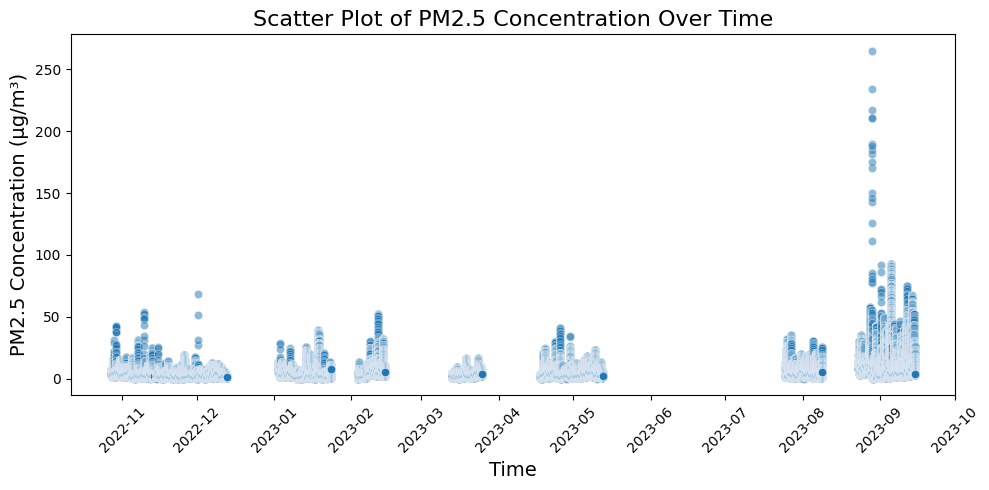

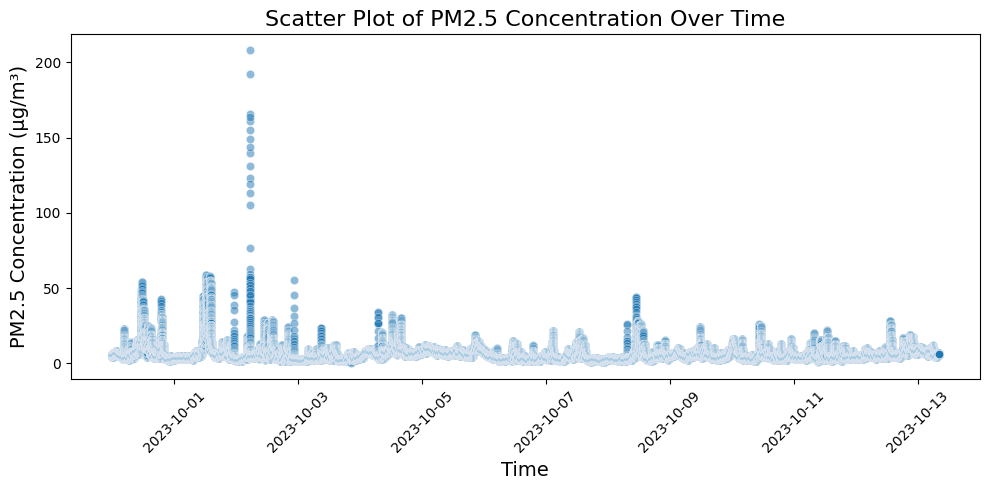

In [11]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='ts_insertion', y='sps30_pm25_ug', data=df2, alpha=0.5)

plt.xlabel('Time', fontsize=14)
plt.ylabel('PM2.5 Concentration (µg/m³)', fontsize=14)
plt.title('Scatter Plot of PM2.5 Concentration Over Time', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
sns.scatterplot(x='ts_insertion', y='sps30_pm25_ug', data=filtered_data_after_sep, alpha=0.5)

plt.xlabel('Time', fontsize=14)
plt.ylabel('PM2.5 Concentration (µg/m³)', fontsize=14)
plt.title('Scatter Plot of PM2.5 Concentration Over Time', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
numeric_cols = df.select_dtypes(include=['float64'])

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (numeric_cols < lower_bound) | (numeric_cols > upper_bound)

outliers_count = outliers.sum()
print(outliers_count)

ads1115_value       210680
ads1115_voltage     211337
scd30_co2           373905
scd30_temp           73966
scd30_hum            54224
sps30_pm05_count    393819
sps30_pm1_count     399387
sps30_pm1_ug        403064
sps30_pm25_count    402879
sps30_pm25_ug       405213
sps30_pm4_count     403460
sps30_pm4_ug        407201
sps30_pm10_count    403574
sps30_pm10_ug       408572
sps30_pm_typ        466865
dtype: int64


In [13]:
filtered_data_after_sep = df[df['ts_insertion'] > '2023-09-30']

In [14]:
# Select only numeric columns (excluding the date column)
numeric_cols = df2.select_dtypes(include=['float64']).columns

# Apply capping for all numeric columns
for col in numeric_cols:
    Q1 = df2[col].quantile(0.25)
    Q3 = df2[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap values above upper bound to the largest non-outlier value
    df2.loc[df2[col] > upper_bound, col] = df2.loc[df2[col] <= upper_bound, col].max()
    # Cap values below lower bound to the smallest non-outlier value
    df2.loc[df2[col] < lower_bound, col] = df2.loc[df2[col] >= lower_bound, col].min()

# Create a new DataFrame for the modified data
filtered_data_after_sep = df2.copy()

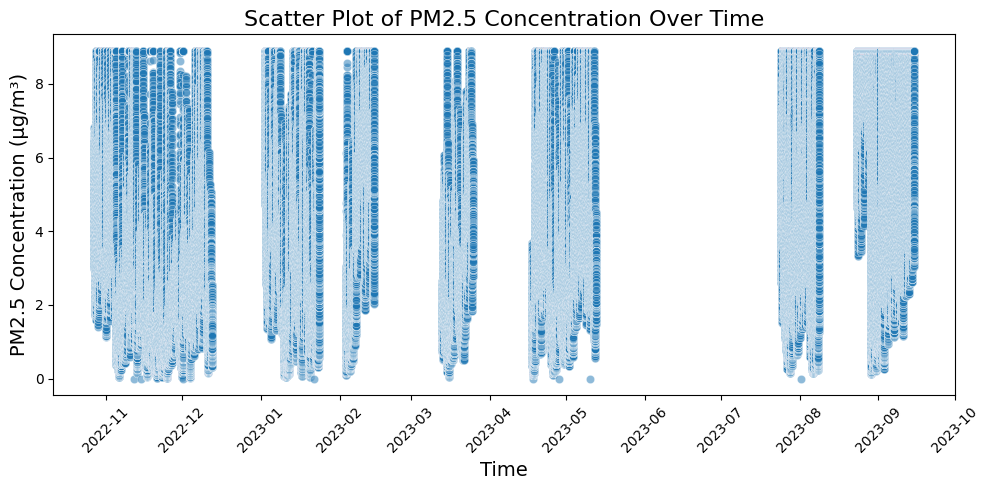

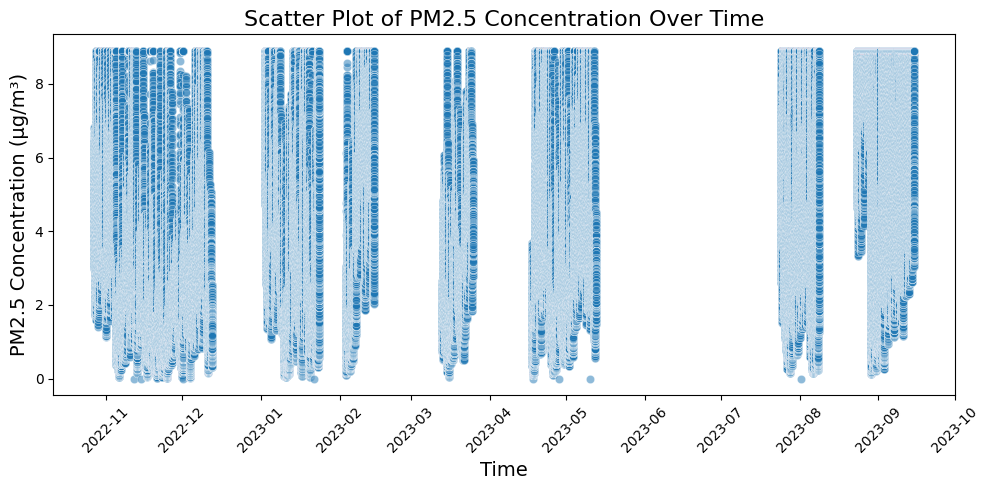

In [16]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='ts_insertion', y='sps30_pm25_ug', data=df2, alpha=0.5)

plt.xlabel('Time', fontsize=14)
plt.ylabel('PM2.5 Concentration (µg/m³)', fontsize=14)
plt.title('Scatter Plot of PM2.5 Concentration Over Time', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
sns.scatterplot(x='ts_insertion', y='sps30_pm25_ug', data=filtered_data_after_sep, alpha=0.5)

plt.xlabel('Time', fontsize=14)
plt.ylabel('PM2.5 Concentration (µg/m³)', fontsize=14)
plt.title('Scatter Plot of PM2.5 Concentration Over Time', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
numeric_cols = df.select_dtypes(include=['float64'])

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (numeric_cols < lower_bound) | (numeric_cols > upper_bound)

outliers_count = outliers.sum()
print(outliers_count)

ads1115_value       210680
ads1115_voltage     211337
scd30_co2            91963
scd30_temp           73966
scd30_hum            54224
sps30_pm05_count    111507
sps30_pm1_count     111303
sps30_pm1_ug        111303
sps30_pm25_count    111312
sps30_pm25_ug       109715
sps30_pm4_count     111298
sps30_pm4_ug        109313
sps30_pm10_count    111298
sps30_pm10_ug       109302
sps30_pm_typ         62782
dtype: int64


In [19]:
df.head()

,ads1115_value,ads1115_voltage,scd30_co2,scd30_temp,scd30_hum,sps30_pm05_count,sps30_pm1_count,sps30_pm1_ug,sps30_pm25_count,sps30_pm25_ug,sps30_pm4_count,sps30_pm4_ug,sps30_pm10_count,sps30_pm10_ug,sps30_pm_typ,ts_insertion
0,1950.0,0.243757,606.316,29.3313,51.7258,26.4676,31.5050,3.97163,31.6969,4.19985,31.7065,4.19985,31.7126,4.19985,0.553393,2022-10-27 10:55:14
1,1997.0,0.249633,605.303,29.3019,51.6693,26.3993,31.4237,3.96138,31.6152,4.18902,31.6247,4.18902,31.6308,4.18902,0.549469,2022-10-27 10:55:16
2,1997.0,0.249633,605.580,29.3153,51.6327,26.4615,31.4977,3.97071,31.6896,4.19888,31.6992,4.19888,31.7053,4.19888,0.550178,2022-10-27 10:55:18
3,1977.0,0.247133,605.191,29.3153,51.7242,26.4615,31.4977,3.97071,31.6896,4.19888,31.6992,4.19888,31.7053,4.19888,0.550178,2022-10-27 10:55:20
4,1957.0,0.244632,603.975,29.3019,51.6556,26.4615,31.4977,3.97071,31.6896,4.19888,31.6992,4.19888,31.7053,4.19888,0.550178,2022-10-27 10:55:22


In [20]:
# Maximum value of 'sps30_pm25_ug'
max_value = df2['sps30_pm25_ug'].max()
print(f"Maximum value of 'sps30_pm25_ug': {max_value}")

# Minimum value of 'sps30_pm25_ug'
min_value = df2['sps30_pm25_ug'].min()
print(f"Minimum value of 'sps30_pm25_ug': {min_value}")

Maximum value of 'sps30_pm25_ug': 8.89663
Minimum value of 'sps30_pm25_ug': 0.0


In [21]:
df2.describe()

,ads1115_value,ads1115_voltage,scd30_co2,scd30_temp,scd30_hum,sps30_pm05_count,sps30_pm1_count,sps30_pm1_ug,sps30_pm25_count,sps30_pm25_ug,sps30_pm4_count,sps30_pm4_ug,sps30_pm10_count,sps30_pm10_ug,sps30_pm_typ,ts_insertion
count,6.000000e+06,6.000000e+06,6.000000e+06,6.000000e+06,6.000000e+06,6.000000e+06,6.000000e+06,6.000000e+06,6.000000e+06,6.000000e+06,6.000000e+06,6.000000e+06,6.000000e+06,6.000000e+06,6.000000e+06,6000000
mean,1.645206e+03,2.056580e-01,6.393083e+02,2.858097e+01,3.732373e+01,2.072632e+01,2.477596e+01,3.129699e+00,2.497481e+01,3.347497e+00,2.498997e+01,3.373385e+00,2.499606e+01,3.378226e+00,5.113986e-01,2023-03-17 01:26:53.303280896
min,1.065000e+03,1.332540e-01,4.831360e+02,2.431370e+01,1.257930e+01,0.000000e+00,0.000000e+00,1.836700e-40,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.160110e-01,2022-10-27 10:55:14
25%,1.494000e+03,1.867560e-01,5.618730e+02,2.752610e+01,3.141330e+01,9.920230e+00,1.186070e+01,1.498840e+00,1.196000e+01,1.610390e+00,1.196910e+01,1.624840e+00,1.197210e+01,1.626980e+00,4.845698e-01,2022-12-05 12:45:12.500000
50%,1.634000e+03,2.042560e-01,6.027210e+02,2.865570e+01,3.867800e+01,1.731680e+01,2.067720e+01,2.610895e+00,2.083520e+01,2.783370e+00,2.084630e+01,2.799960e+00,2.085110e+01,2.803090e+00,5.046460e-01,2023-02-13 02:51:08
75%,1.780000e+03,2.225070e-01,6.905550e+02,2.967040e+01,4.396970e+01,2.809560e+01,3.350480e+01,4.229300e+00,3.375060e+01,4.524890e+00,3.376920e+01,4.549270e+00,3.377710e+01,4.553620e+00,5.302780e-01,2023-05-12 07:21:29.500000
max,2.209000e+03,2.761330e-01,8.835770e+02,3.288280e+01,5.831600e+01,5.535860e+01,6.597090e+01,8.324980e+00,6.643630e+01,8.896630e+00,6.646920e+01,8.935910e+00,6.648460e+01,8.943570e+00,5.988400e-01,2023-09-15 03:06:01
std,2.249040e+02,2.811289e-02,1.052940e+02,1.527821e+00,8.879488e+00,1.407376e+01,1.683019e+01,2.125615e+00,1.696271e+01,2.271937e+00,1.697232e+01,2.290770e+00,1.697640e+01,2.294669e+00,3.824642e-02,NaN


In [23]:
numeric_cols = df.select_dtypes(include=['float64', 'int64'])
mean_values = numeric_cols.mean()
std_values = numeric_cols.std()

In [25]:
print("Mean value of the dataset:")
print(mean_values)
print("\nStandard Deviation of the dataset:")
print(std_values)

Mean value of the dataset:
ads1115_value       1.648561e+03
ads1115_voltage     2.060773e-01
scd30_co2           6.509388e+02
scd30_temp          2.870989e+01
scd30_hum           3.883759e+01
sps30_pm05_count    4.779640e+31
sps30_pm1_count     4.779640e+31
sps30_pm1_ug        3.417439e+00
sps30_pm25_count    4.779499e+31
sps30_pm25_ug       4.779640e+31
sps30_pm4_count     4.779499e+31
sps30_pm4_ug        4.779640e+31
sps30_pm10_count    4.779499e+31
sps30_pm10_ug       4.779640e+31
sps30_pm_typ        4.779499e+31
dtype: float64

Standard Deviation of the dataset:
ads1115_value       2.119458e+02
ads1115_voltage     2.649313e-02
scd30_co2           1.168066e+02
scd30_temp          1.539335e+00
scd30_hum           8.989558e+00
sps30_pm05_count    1.274063e+35
sps30_pm1_count     1.274063e+35
sps30_pm1_ug        2.566108e+00
sps30_pm25_count    1.274063e+35
sps30_pm25_ug       1.274063e+35
sps30_pm4_count     1.274063e+35
sps30_pm4_ug        1.274063e+35
sps30_pm10_count    1.274063e+3

In [31]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Z-skorunu hesaplama
df_zscore = (df[numeric_cols] - df[numeric_cols].mean()) / df[numeric_cols].std()

# Z-skoru 3'ten büyük olan verileri filtreleme
df_cleaned = df[(df_zscore.abs() < 3).all(axis=1)]

# Sonuç
print("Temizlenmiş Veri Kümesi:")
print(df_cleaned)

Temizlenmiş Veri Kümesi:
         ads1115_value  ads1115_voltage  scd30_co2  scd30_temp  scd30_hum  \
0               1950.0         0.243757    606.316     29.3313    51.7258   
1               1997.0         0.249633    605.303     29.3019    51.6693   
2               1997.0         0.249633    605.580     29.3153    51.6327   
3               1977.0         0.247133    605.191     29.3153    51.7242   
4               1957.0         0.244632    603.975     29.3019    51.6556   
...                ...              ...        ...         ...        ...   
7105446         1663.0         0.207881    713.675     28.1483    43.4067   
7105447         1664.0         0.208006    713.536     28.1483    43.3792   
7105448         1645.0         0.205631    713.131     28.1617    43.3243   
7105449         1664.0         0.207881    711.359     28.1617    43.3655   
7105450         1656.0         0.207006    710.733     28.1483    43.3929   

         sps30_pm05_count  sps30_pm1_count  sps30_

In [34]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

df_zscore = (df[numeric_cols] - df[numeric_cols].mean()) / df[numeric_cols].std()

outliers_before = (df_zscore.abs() > 3).sum().sum()

df_cleaned = df[(df_zscore.abs() < 3).all(axis=1)]

df_zscore_cleaned = (df_cleaned[numeric_cols] - df_cleaned[numeric_cols].mean()) / df_cleaned[numeric_cols].std()
outliers_after = (df_zscore_cleaned.abs() > 3).sum().sum()

print(f"Number of the outliers before cleaning with Z-Score: {outliers_before}")
print(f"Number of the outliers after cleaning with Z-Score: {outliers_after}")

Number of the outliers before cleaning with Z-Score: 120510
Number of the outliers after cleaning with Z-Score: 100333
